# 03 - Cox proportional hazards: driver analysis with a clock

Kaplan-Meier compares groups one at a time. Cox proportional hazards lets us ask:

> Holding other variables constant, which customer characteristics are associated with faster or slower churn?

The output is usually a **hazard ratio**.

- `hazard ratio > 1`: higher instantaneous event rate.
- `hazard ratio < 1`: lower instantaneous event rate.
- `hazard ratio = 1`: no estimated effect.

A hazard ratio is not a probability. It is a multiplier on the event rate at each point in time.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
churn = pd.read_csv(DATA_DIR / "service_churn_drivers.csv")
churn.head()

,customer_id,plan,industry,seats,monthly_fee,login_days_30,support_tickets_30,discount_pct,training_completed,duration_days,churn_observed
0,S00001,Pro,Manufacturing,5,84.30,15,2,30,1,296,0
1,S00002,Pro,Manufacturing,4,89.26,16,1,20,1,91,1
2,S00003,Basic,Manufacturing,1,47.33,11,4,0,0,69,1
3,S00004,Basic,SaaS,3,60.42,8,2,0,0,128,1
4,S00005,Basic,Manufacturing,5,70.91,4,2,0,0,62,1


In [3]:
churn[["duration_days", "churn_observed", "login_days_30", "support_tickets_30", "discount_pct"]].describe().round(2)

,duration_days,churn_observed,login_days_30,support_tickets_30,discount_pct
count,1600.00,1600.00,1600.00,1600.00,1600.00
mean,180.64,0.49,10.15,1.23,7.12
std,99.89,0.50,4.31,1.15,8.78
min,1.00,0.00,0.00,0.00,0.00
25%,95.00,0.00,7.00,0.00,0.00
50%,186.00,0.00,10.00,1.00,5.00
75%,259.00,1.00,13.00,2.00,10.00
max,365.00,1.00,27.00,9.00,30.00


## Prepare model data

The survival target columns are:

- `duration_days`: how long we observed the customer.
- `churn_observed`: 1 if churn happened, 0 if the row is censored.

Those columns must never be included as predictors. They are the target.

In [4]:
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter

model_df = churn.drop(columns=["customer_id"]).copy()
model_df = pd.get_dummies(model_df, columns=["plan", "industry"], drop_first=True)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=42,
    stratify=model_df["churn_observed"],
)

print("train rows:", len(train_df), "test rows:", len(test_df))
print("train event rate:", round(train_df["churn_observed"].mean(), 3))
print("test event rate:", round(test_df["churn_observed"].mean(), 3))

train rows: 1200 test rows: 400
train event rate: 0.494
test event rate: 0.495


In [5]:
cph = CoxPHFitter(penalizer=0.03)
cph.fit(train_df, duration_col="duration_days", event_col="churn_observed")

print("Train concordance:", round(cph.concordance_index_, 3))
print("Test concordance:", round(cph.score(test_df, scoring_method="concordance_index"), 3))
cph.summary[["coef", "exp(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"]].round(3)

Train concordance: 0.719
Test concordance: 0.714


,coef,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,
seats,-0.009,0.991,0.650,0.953,1.031
monthly_fee,-0.001,0.999,0.507,0.995,1.003
login_days_30,-0.042,0.959,0.001,0.934,0.983
support_tickets_30,0.212,1.236,0.000,1.157,1.321
discount_pct,-0.035,0.965,0.000,0.956,0.975
training_completed,-0.460,0.632,0.000,0.536,0.744
plan_Enterprise,-0.612,0.542,0.032,0.310,0.949
plan_Pro,-0.627,0.534,0.000,0.425,0.671
industry_Manufacturing,-0.080,0.923,0.466,0.743,1.145


In [6]:
hazard_ratios = (
    cph.summary[["exp(coef)", "p"]]
    .rename(columns={"exp(coef)": "hazard_ratio"})
    .sort_values("hazard_ratio", ascending=False)
)
hazard_ratios.assign(
    interpretation=np.where(
        hazard_ratios["hazard_ratio"] > 1,
        "faster churn",
        "slower churn",
    )
).round(3)

,hazard_ratio,p,interpretation
covariate,,,
support_tickets_30,1.236,0.000,faster churn
industry_Retail,1.188,0.111,faster churn
industry_SaaS,1.093,0.407,faster churn
monthly_fee,0.999,0.507,slower churn
seats,0.991,0.650,slower churn
discount_pct,0.965,0.000,slower churn
login_days_30,0.959,0.001,slower churn
industry_Manufacturing,0.923,0.466,slower churn
training_completed,0.632,0.000,slower churn


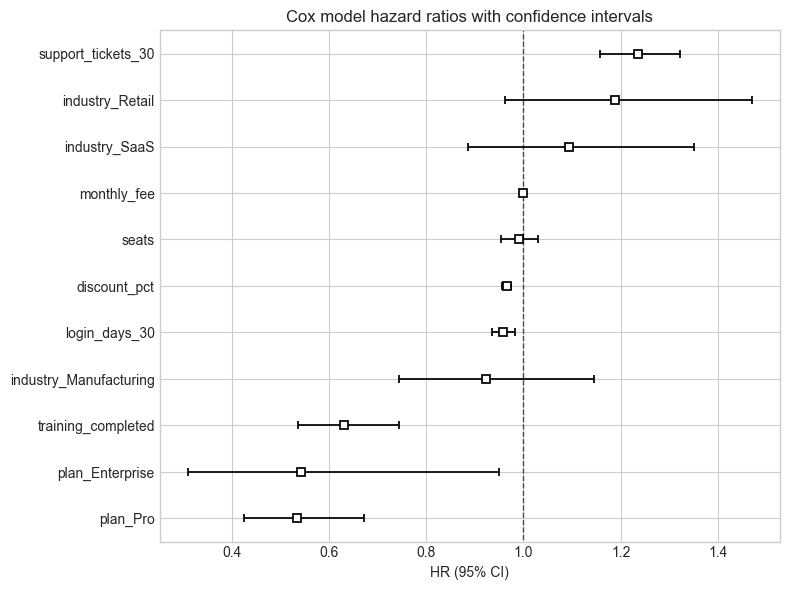

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
cph.plot(hazard_ratios=True, ax=ax)
ax.set_title("Cox model hazard ratios with confidence intervals")
plt.tight_layout()
plt.show()

## Predict survival curves for two customer profiles

Cox is semi-parametric:

- It learns a baseline hazard curve from the data.
- It shifts that curve up or down using customer features.

That lets us compare two realistic personas without claiming that any single coefficient is destiny.

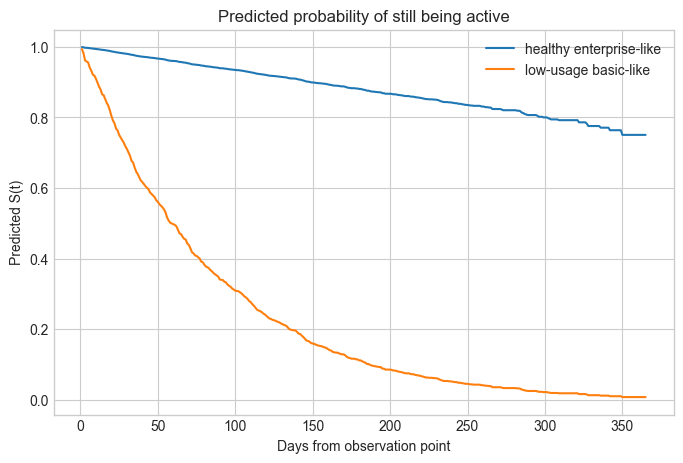

,persona,P(active at day 90),P(active at day 180)
0,healthy enterprise-like,0.94,0.881
1,low-usage basic-like,0.34,0.111


In [8]:
feature_cols = [c for c in train_df.columns if c not in ["duration_days", "churn_observed"]]
reference = train_df[feature_cols].median().to_frame().T

low_risk = reference.copy()
low_risk["login_days_30"] = 24
low_risk["support_tickets_30"] = 0
low_risk["training_completed"] = 1
if "plan_Enterprise" in low_risk:
    low_risk["plan_Enterprise"] = 1
if "plan_Pro" in low_risk:
    low_risk["plan_Pro"] = 0

high_risk = reference.copy()
high_risk["login_days_30"] = 2
high_risk["support_tickets_30"] = 4
high_risk["training_completed"] = 0
if "plan_Enterprise" in high_risk:
    high_risk["plan_Enterprise"] = 0
if "plan_Pro" in high_risk:
    high_risk["plan_Pro"] = 0

personas = pd.concat([low_risk, high_risk], ignore_index=True)
personas.index = ["healthy enterprise-like", "low-usage basic-like"]

survival = cph.predict_survival_function(personas, times=np.arange(1, 366))
ax = survival.plot(figsize=(8, 5))
ax.set_title("Predicted probability of still being active")
ax.set_xlabel("Days from observation point")
ax.set_ylabel("Predicted S(t)")
plt.show()

pd.DataFrame({
    "persona": personas.index,
    "P(active at day 90)": cph.predict_survival_function(personas, times=[90]).T[90].round(3).values,
    "P(active at day 180)": cph.predict_survival_function(personas, times=[180]).T[180].round(3).values,
})

## What to say in a business review

Strong version:

> After controlling for plan, industry, seats, discount, and training completion, low product usage and more support tickets are associated with faster churn. The model separates higher-risk from lower-risk customers on a held-out test set, and the survival curves translate that into expected retention at 90 and 180 days.

Weak version:

> The model says support tickets cause churn.

Cox can support driver analysis, but causal language requires experiment design or much stronger assumptions.